# pandas-dev/pandas Issue Classifier — Training Notebook

**Run on Google Colab with a T4 GPU runtime.**

## What this notebook does
1. Loads pre-processed JSONL splits produced by local scripts
2. Trains three classifiers on identical data:
   - **TF-IDF + Logistic Regression** (classical ML baseline)
   - **Fine-tuned DistilBERT** (deep learning)
   - **GPT-4o-mini zero-shot** (LLM baseline)
3. Produces a side-by-side macro-F1 / latency / cost comparison
4. Saves weights + model card (with SHA-256) to MinIO or Google Drive

## Before you run
- Set Runtime → Change runtime type → **T4 GPU**
- Add secrets in the left sidebar (key icon): `OPENAI_API_KEY`, `WANDB_API_KEY`,
  `MINIO_ENDPOINT`, `MINIO_ACCESS_KEY`, `MINIO_SECRET_KEY`
- Upload `train.jsonl`, `val.jsonl`, `test.jsonl` (from `data/`) to `/content/` via
  the Files panel (folder icon on left sidebar)


In [1]:
# ── 0.1  Install packages ──────────────────────────────────────────────────
# Use >= constraints so Colab's pre-installed packages are not downgraded.
!pip install -q \
    "transformers>=4.43.0" \
    "datasets>=2.19.0" \
    "accelerate>=0.34.0" \
    "wandb>=0.19.0" \
    "minio>=7.2.7" \
    "scikit-learn>=1.5.0" \
    "beautifulsoup4>=4.12.3" \
    "openai>=1.30.0" \
    "seaborn>=0.13.2" \
    "tenacity>=8.3.0" \
    "protobuf>=5.28.3"

print("Packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 61.7 MB/s eta 0:00:00
Packages installed.


In [2]:
# ── 0.2  Imports ───────────────────────────────────────────────────────────
import hashlib
import json
import os
import pickle
import time
import warnings
from collections import Counter
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import wandb
from datasets import Dataset as HFDataset
from minio import Minio
from openai import OpenAI
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from tenacity import retry, stop_after_attempt, wait_exponential
from transformers import (
    DataCollatorWithPadding,
    DistilBertForSequenceClassification,
    DistilBertTokenizerFast,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
# ── 0.3  Secrets + Configuration ──────────────────────────────────────────
try:
    from google.colab import userdata

    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def _secret(key, default=""):
    if IN_COLAB:
        try:
            return userdata.get(key) or default
        except Exception:
            return default
    return os.environ.get(key, default)


OPENAI_API_KEY = _secret("OPENAI_API_KEY")
WANDB_API_KEY = _secret("WANDB_API_KEY")
MINIO_ENDPOINT = _secret("MINIO_ENDPOINT", "localhost:9000")
MINIO_ACCESS = _secret("MINIO_ACCESS_KEY", "minioadmin")
MINIO_SECRET = _secret("MINIO_SECRET_KEY", "minioadmin_dev")

assert OPENAI_API_KEY, "OPENAI_API_KEY is missing — add it in the Secrets tab (lock icon)"
assert WANDB_API_KEY, "WANDB_API_KEY is missing — add it in the Secrets tab (lock icon)"

# Label mapping -- must match scripts/process_issues.py exactly
CLASSES = ["bug", "feature", "docs", "question"]
LABEL2ID = {c: i for i, c in enumerate(CLASSES)}
ID2LABEL = {i: c for c, i in LABEL2ID.items()}

JSONL_DIR = Path("/content") if IN_COLAB else Path("data")
DATA_DIR = Path("/content/data") if IN_COLAB else Path("data")
CKPT_DIR = Path("/content/checkpoints") if IN_COLAB else Path("checkpoints")
DATA_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

MAX_TOKENS = 512

print(f"IN_COLAB: {IN_COLAB}")
print(f"OPENAI_API_KEY set: {bool(OPENAI_API_KEY)}")
print(f"WANDB_API_KEY set:  {bool(WANDB_API_KEY)}")
print("Configuration ready.")
print(f"JSONL input: {JSONL_DIR}")
print(f"Artifacts:   {DATA_DIR}")

IN_COLAB: True
OPENAI_API_KEY set: True
WANDB_API_KEY set:  True
Configuration ready.
JSONL input: /content
Artifacts:   /content/data


In [4]:
# ── 1.  Load pre-processed splits ─────────────────────────────────────────
#
# Files produced locally by:
#   python scripts/download_issues.py
#   python scripts/process_issues.py
# then uploaded to Colab via the Files sidebar (folder icon → Upload).


def load_jsonl(path):
    records = []
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


train_records = load_jsonl(JSONL_DIR / "train.jsonl")
val_records = load_jsonl(JSONL_DIR / "val.jsonl")
test_records = load_jsonl(JSONL_DIR / "test.jsonl")

X_train = [r["text"] for r in train_records]
y_train = [r["label"] for r in train_records]
X_val = [r["text"] for r in val_records]
y_val = [r["label"] for r in val_records]
X_test = [r["text"] for r in test_records]
y_test = [r["label"] for r in test_records]

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print()
print("Class distribution:")
for split_name, labels in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = Counter(labels)
    row = "  ".join(f"{c}={counts.get(c, 0)}" for c in CLASSES)
    print(f"  {split_name:<6}: {row}")
print()
train_start = train_records[0]["created_at"][:10]
train_end = train_records[-1]["created_at"][:10]
test_start = test_records[0]["created_at"][:10]
test_end = test_records[-1]["created_at"][:10]
print(f"Train dates: {train_start} -> {train_end}")
print(f"Test  dates: {test_start}  -> {test_end}")

Train: 10,012  Val: 2,145  Test: 2,146

Class distribution:
  train : bug=5073  feature=2140  docs=1502  question=1297
  val   : bug=1287  feature=323  docs=316  question=219
  test  : bug=1343  feature=331  docs=394  question=78

Train dates: 2010-09-29 -> 2021-08-09
Test  dates: 2023-05-30  -> 2026-05-19


## 5. Model 1 — TF-IDF + Logistic Regression (Classical ML Baseline)

### Why this is the required baseline
The assignment mandates a three-way comparison. Classical ML is the cheapest, fastest,
most interpretable option — it sets the floor that the other two models must beat.

### TF-IDF choices
- `max_features=100_000`: captures the most discriminative vocabulary
- `ngram_range=(1, 2)`: unigrams + bigrams (`null pointer`, `data frame` are strong signals)
- `sublinear_tf=True`: `1 + log(TF)` — reduces influence of repeated stack-trace lines
- `min_df=2`: ignore terms appearing in only 1 document

### Critical rule: fit TF-IDF on TRAIN only
The vectorizer must never see val or test data during fitting.


Fitting TF-IDF on train split only ...
Vocabulary size: 71,106
Train matrix: (10012, 71106)

Training Logistic Regression ...
Done.

Val  macro-F1:  0.7854
Test macro-F1:  0.8404

Test classification report:
              precision    recall  f1-score   support

         bug       0.95      0.96      0.95      1343
     feature       0.93      0.91      0.92       394
        docs       0.92      0.86      0.89       331
    question       0.56      0.64      0.60        78

    accuracy                           0.92      2146
   macro avg       0.84      0.84      0.84      2146
weighted avg       0.93      0.92      0.92      2146



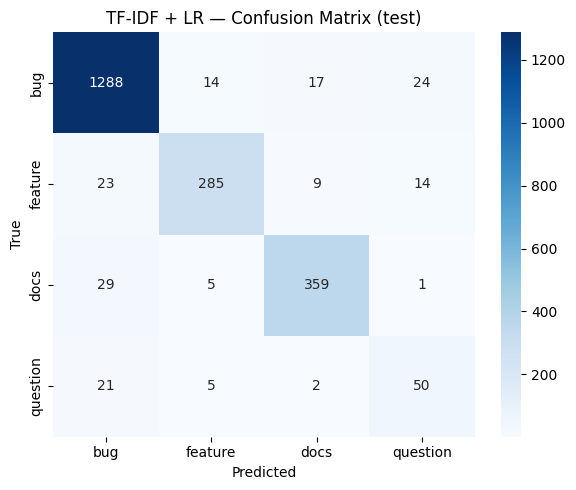


Latency: 0.015 ms/issue
TF-IDF vectorizer + LR model saved.


In [5]:
# ── 5.1  TF-IDF + Logistic Regression ─────────────────────────────────────

print("Fitting TF-IDF on train split only ...")
tfidf = TfidfVectorizer(
    max_features=100_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    strip_accents="unicode",
    analyzer="word",
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"Train matrix: {X_train_tfidf.shape}")

print("\nTraining Logistic Regression ...")
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    C=1.0,
    solver="lbfgs",
    multi_class="multinomial",
    random_state=SEED,
    n_jobs=-1,
)
lr.fit(X_train_tfidf, y_train)
print("Done.")

y_val_pred = lr.predict(X_val_tfidf)
y_test_pred = lr.predict(X_test_tfidf)

lr_val_f1 = f1_score(y_val, y_val_pred, average="macro")
lr_test_f1 = f1_score(y_test, y_test_pred, average="macro")

print(f"\nVal  macro-F1:  {lr_val_f1:.4f}")
print(f"Test macro-F1:  {lr_test_f1:.4f}")
print("\nTest classification report:")
print(classification_report(y_test, y_test_pred, target_names=CLASSES))

cm_lr = confusion_matrix(y_test, y_test_pred, labels=CLASSES)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_lr, annot=True, fmt="d", xticklabels=CLASSES, yticklabels=CLASSES, cmap="Blues", ax=ax
)
ax.set_title("TF-IDF + LR — Confusion Matrix (test)")
ax.set_ylabel("True")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig(DATA_DIR / "cm_lr.png", dpi=120)
plt.show()

N_LATENCY = 100
sample_vec = tfidf.transform(X_test[:N_LATENCY])
t0 = time.perf_counter()
for _ in range(10):
    lr.predict(sample_vec)
lr_latency_ms = (time.perf_counter() - t0) / 10 / N_LATENCY * 1000
print(f"\nLatency: {lr_latency_ms:.3f} ms/issue")

results_lr = {
    "model": "TF-IDF + LR",
    "val_macro_f1": round(lr_val_f1, 4),
    "test_macro_f1": round(lr_test_f1, 4),
    "per_class_f1": dict(
        zip(CLASSES, f1_score(y_test, y_test_pred, average=None, labels=CLASSES).tolist())
    ),
    "latency_ms": round(lr_latency_ms, 3),
    "cost_per_call": 0.0,
}

with open(DATA_DIR / "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)
with open(DATA_DIR / "lr_model.pkl", "wb") as f:
    pickle.dump(lr, f)
print("TF-IDF vectorizer + LR model saved.")

## 6. Model 2 — Fine-tuned DistilBERT

### Architecture
```
Input: "title [SEP] body" (max 512 tokens)
  ↓  DistilBertForSequenceClassification (66M params)
  ↓  [CLS] → Dropout(0.1) → Linear(768 → 4) → Softmax
  ↓  bug / feature / docs / question
```

### Key training decisions
- **Full fine-tune**: All 6 transformer blocks update — GitHub issues are domain-shifted from Wikipedia
- **Inverse-frequency class weights**: minority `question` class up-weighted ~2.3×
- **Linear warmup 10%**: prevents catastrophic forgetting in early batches
- **Early stopping patience=2**: stops when val macro-F1 plateaus
- **fp16 on T4**: ~30% speed-up via Tensor Cores


In [6]:
# ── 6.1  Tokenize + build HuggingFace Datasets ────────────────────────────

MODEL_NAME = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)


def make_hf_dataset(texts: list, labels: list) -> HFDataset:
    dataset = HFDataset.from_dict(
        {
            "text": texts,
            "label": [LABEL2ID[l] for l in labels],
        }
    )

    def tokenize(batch):
        return tokenizer(
            batch["text"],
            max_length=MAX_TOKENS,
            truncation=True,
            padding=False,
        )

    return dataset.map(tokenize, batched=True, remove_columns=["text"])


print("Tokenizing splits ...")
train_ds = make_hf_dataset(X_train, y_train)
val_ds = make_hf_dataset(X_val, y_val)
test_ds = make_hf_dataset(X_test, y_test)

train_ds.set_format("torch")
val_ds.set_format("torch")
test_ds.set_format("torch")

print(f"Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing splits ...


Map:   0%|          | 0/10012 [00:00<?, ? examples/s]

Map:   0%|          | 0/2145 [00:00<?, ? examples/s]

Map:   0%|          | 0/2146 [00:00<?, ? examples/s]

Train: 10,012  Val: 2,145  Test: 2,146


In [7]:
# ── 6.2  Inverse-frequency class weights ──────────────────────────────────

class_counts = Counter(y_train)
n_train = len(y_train)

raw_weights = np.array([n_train / (len(CLASSES) * class_counts[cls]) for cls in CLASSES])
normalized_weights = raw_weights / raw_weights.mean()
class_weights_tensor = torch.FloatTensor(normalized_weights)

print("Class weights (normalized, mean=1):")
for cls, raw, norm in zip(CLASSES, raw_weights, normalized_weights):
    print(f"  {cls:<12} count={class_counts[cls]:>5,}  raw={raw:.4f}  normalized={norm:.4f}")

Class weights (normalized, mean=1):
  bug          count=5,073  raw=0.4934  normalized=0.3753
  feature      count=2,140  raw=1.1696  normalized=0.8896
  docs         count=1,502  raw=1.6664  normalized=1.2674
  question     count=1,297  raw=1.9298  normalized=1.4678


In [8]:
# ── 6.3  WeightedLossTrainer + compute_metrics ────────────────────────────


class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights: torch.Tensor, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fn(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, preds, average="macro")
    per_class_f1 = f1_score(labels, preds, average=None, labels=list(range(len(CLASSES))))
    accuracy = accuracy_score(labels, preds)
    return {
        "macro_f1": macro_f1,
        "accuracy": accuracy,
        **{f"f1_{cls}": per_class_f1[i] for i, cls in enumerate(CLASSES)},
    }


print("WeightedLossTrainer and compute_metrics defined.")

WeightedLossTrainer and compute_metrics defined.


In [10]:
# ── 6.4  TrainingArguments + W&B init + Train ─────────────────────────────

wandb.login(key=WANDB_API_KEY)
wandb.init(
    project="maintainers-copilot",
    name="distilbert-pandas-classifier",
    config={
        "model": MODEL_NAME,
        "learning_rate": 2e-5,
        "batch_size": 16,
        "grad_accum": 2,
        "max_epochs": 5,
        "warmup_ratio": 0.1,
        "weight_decay": 0.01,
        "max_length": MAX_TOKENS,
        "class_weights": normalized_weights.tolist(),
        "early_stopping": 2,
        "n_train": len(X_train),
        "n_val": len(X_val),
        "n_test": len(X_test),
    },
)

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(CLASSES),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

training_args = TrainingArguments(
    output_dir=str(CKPT_DIR),
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=2,
    warmup_ratio=0.10,
    learning_rate=2e-5,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="wandb",
    run_name="distilbert-pandas-classifier",
    fp16=(DEVICE == "cuda"),
    dataloader_num_workers=2,
    seed=SEED,
    max_grad_norm=1.0,
)

trainer = WeightedLossTrainer(
    class_weights=class_weights_tensor,
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting training ...")
print("Expected time: ~8 min/epoch on T4 x up to 5 epochs = up to 40 min")
train_result = trainer.train()
print("Training complete.")
print(f"Best checkpoint: {trainer.state.best_model_checkpoint}")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting training ...
Expected time: ~8 min/epoch on T4 x up to 5 epochs = up to 40 min


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy,F1 Bug,F1 Feature,F1 Docs,F1 Question
1,1.437500,0.592485,0.797574,0.881119,0.919337,0.897661,0.886633,0.486667
2,1.226958,0.536141,0.809531,0.889044,0.927706,0.916923,0.890388,0.503106
3,1.008106,0.529393,0.779763,0.839627,0.883556,0.911854,0.860759,0.462882
4,0.853957,0.560155,0.791448,0.862471,0.904183,0.906627,0.875817,0.479167


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training complete.
Best checkpoint: /content/checkpoints/checkpoint-626


Val  macro-F1 (best epoch): 0.8095
Test macro-F1:              0.8867

Test classification report:
              precision    recall  f1-score   support

         bug       0.96      0.98      0.97      1343
     feature       0.97      0.90      0.93       394
        docs       0.96      0.93      0.95       331
    question       0.70      0.69      0.70        78

    accuracy                           0.95      2146
   macro avg       0.90      0.88      0.89      2146
weighted avg       0.95      0.95      0.95      2146



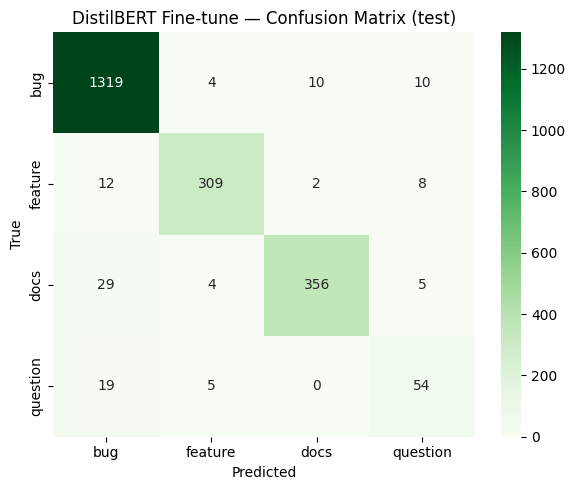


Latency (CPU, single issue): 469.6 ms


eval/accuracy,▇█▁▄
eval/f1_bug,▇█▁▄
eval/f1_docs,▇█▁▅
eval/f1_feature,▁█▆▄
eval/f1_question,▅█▁▄
eval/loss,█▂▁▄
eval/macro_f1,▅█▁▄
eval/runtime,▁██▅
eval/samples_per_second,█▁▁▄
eval/steps_per_second,█▁▁▄
+16,...


Results stored.


In [11]:
# ── 6.5  Evaluate on test set + confusion matrix + latency ────────────────

test_output = trainer.predict(test_ds)
y_test_pred_ids = np.argmax(test_output.predictions, axis=-1)
y_test_pred_bert = [ID2LABEL[i] for i in y_test_pred_ids]

distilbert_val_f1 = trainer.state.best_metric
distilbert_test_f1 = f1_score(y_test, y_test_pred_bert, average="macro")

print(f"Val  macro-F1 (best epoch): {distilbert_val_f1:.4f}")
print(f"Test macro-F1:              {distilbert_test_f1:.4f}")
print("\nTest classification report:")
print(classification_report(y_test, y_test_pred_bert, target_names=CLASSES))

cm_bert = confusion_matrix(y_test, y_test_pred_bert, labels=CLASSES)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_bert, annot=True, fmt="d", xticklabels=CLASSES, yticklabels=CLASSES, cmap="Greens", ax=ax
)
ax.set_title("DistilBERT Fine-tune — Confusion Matrix (test)")
ax.set_ylabel("True")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig(DATA_DIR / "cm_distilbert.png", dpi=120)
plt.show()

model.eval()
model_cpu = model.cpu()
sample_enc = tokenizer(
    X_test[:1], max_length=MAX_TOKENS, truncation=True, padding=True, return_tensors="pt"
)
with torch.no_grad():
    for _ in range(5):
        model_cpu(**sample_enc)
t0 = time.perf_counter()
N_REPS = 50
with torch.no_grad():
    for _ in range(N_REPS):
        model_cpu(**sample_enc)
bert_latency_ms = (time.perf_counter() - t0) / N_REPS * 1000
print(f"\nLatency (CPU, single issue): {bert_latency_ms:.1f} ms")

results_distilbert = {
    "model": "DistilBERT fine-tune",
    "val_macro_f1": round(distilbert_val_f1, 4),
    "test_macro_f1": round(distilbert_test_f1, 4),
    "per_class_f1": dict(
        zip(CLASSES, f1_score(y_test, y_test_pred_bert, average=None, labels=CLASSES).tolist())
    ),
    "latency_ms": round(bert_latency_ms, 1),
    "cost_per_call": 0.0,
}

wandb.log(
    {
        "test/macro_f1": distilbert_test_f1,
        "test/latency_ms": bert_latency_ms,
        **{f"test/f1_{cls}": results_distilbert["per_class_f1"][cls] for cls in CLASSES},
    }
)
wandb.finish()
print("Results stored.")

## 7. Model 3 — GPT-4o-mini Zero-shot (LLM Baseline)

### Why this is a required baseline
Zero-shot LLM classification = ceiling achievable with **no training data**.
If LLM beats fine-tuned DistilBERT, that means fine-tuning has a bug or the dataset is too small.

### Design choices
- **JSON mode**: Forces valid JSON output — prevents parsing failures
- **Temperature=0**: Deterministic, reproducible
- **Full test set**: ~$0.24 total at current pricing
- **Rate limiting**: 0.15s sleep → ~400 RPM, under the 500 RPM default limit


In [13]:
# ── 7.1  LLM classify function ─────────────────────────────────────────────

openai_client = OpenAI(api_key=OPENAI_API_KEY.strip())

SYSTEM_PROMPT = """You are an expert at triaging GitHub issues for the pandas open-source library.
Classify the issue into exactly one of these four categories:
- bug: A defect in existing behavior. Something that used to work or should work but doesn't.
- feature: A request for new functionality or an enhancement to existing behavior.
- docs: A problem with documentation, docstrings, examples, or the website.
- question: A usage question about how pandas works. The reporter wants to understand something, not report a defect.

Respond with ONLY valid JSON: {"label": "<one of: bug, feature, docs, question>"}"""


@retry(
    stop=stop_after_attempt(5),
    wait=wait_exponential(multiplier=2, min=2, max=60),
    reraise=True,
)
def classify_with_llm(text: str) -> str:
    resp = openai_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": text[:3000]},
        ],
        temperature=0,
        max_tokens=20,
        response_format={"type": "json_object"},
    )
    try:
        result = json.loads(resp.choices[0].message.content)
        label = result.get("label", "bug").lower().strip()
        return label if label in CLASSES else "bug"
    except Exception:
        return "bug"


print("LLM classify function defined.")
test_pred = classify_with_llm(X_test[0])
print(f"Smoke test — true: {y_test[0]}, predicted: {test_pred}")

LLM classify function defined.
Smoke test — true: bug, predicted: bug


  100/2146  elapsed=82s  ETA=1674s
  200/2146  elapsed=163s  ETA=1586s
  300/2146  elapsed=257s  ETA=1580s
  400/2146  elapsed=339s  ETA=1478s
  500/2146  elapsed=439s  ETA=1446s
  600/2146  elapsed=538s  ETA=1386s
  700/2146  elapsed=630s  ETA=1301s
  800/2146  elapsed=706s  ETA=1188s
  900/2146  elapsed=833s  ETA=1153s
  1000/2146  elapsed=919s  ETA=1053s
  1100/2146  elapsed=994s  ETA=945s
  1200/2146  elapsed=1088s  ETA=857s
  1300/2146  elapsed=1181s  ETA=768s
  1400/2146  elapsed=1263s  ETA=673s
  1500/2146  elapsed=1351s  ETA=582s
  1600/2146  elapsed=1441s  ETA=492s
  1700/2146  elapsed=1517s  ETA=398s
  1800/2146  elapsed=1614s  ETA=310s
  1900/2146  elapsed=1694s  ETA=219s
  2000/2146  elapsed=1777s  ETA=130s
  2100/2146  elapsed=1864s  ETA=41s
LLM predictions saved to /content/data/llm_predictions.json

Test macro-F1 (LLM zero-shot): 0.9030

Test classification report:
              precision    recall  f1-score   support

         bug       0.95      0.99      0.97      134

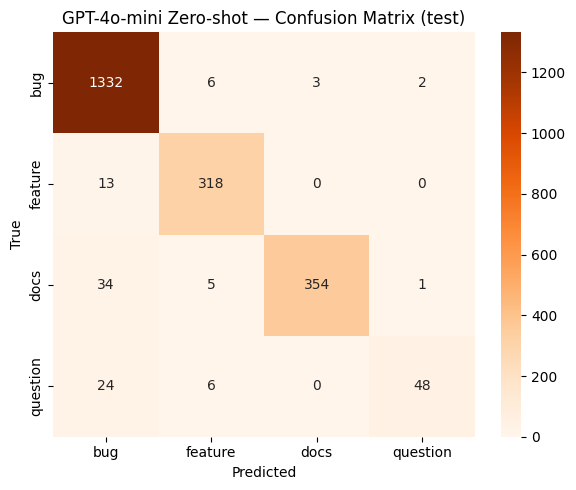

Latency: 775 ms/call
Cost:    $0.000078/call


In [14]:
# ── 7.2  Batch evaluation on full test set ─────────────────────────────────
# Estimated time: ~5-6 min at 400 RPM.  Estimated cost: ~$0.24.

LLM_CACHE_FILE = DATA_DIR / "llm_predictions.json"

if LLM_CACHE_FILE.exists():
    y_test_pred_llm = json.loads(LLM_CACHE_FILE.read_text())
    print(f"Loaded cached LLM predictions ({len(y_test_pred_llm)} items).")
else:
    y_test_pred_llm = []
    n = len(X_test)
    t_start = time.time()
    for i, text in enumerate(X_test):
        pred = classify_with_llm(text)
        y_test_pred_llm.append(pred)
        time.sleep(0.15)
        if (i + 1) % 100 == 0:
            elapsed = time.time() - t_start
            eta = elapsed / (i + 1) * (n - i - 1)
            print(f"  {i + 1}/{n}  elapsed={elapsed:.0f}s  ETA={eta:.0f}s")
    LLM_CACHE_FILE.write_text(json.dumps(y_test_pred_llm))
    print(f"LLM predictions saved to {LLM_CACHE_FILE}")

llm_test_f1 = f1_score(y_test, y_test_pred_llm, average="macro")
print(f"\nTest macro-F1 (LLM zero-shot): {llm_test_f1:.4f}")
print("\nTest classification report:")
print(classification_report(y_test, y_test_pred_llm, target_names=CLASSES))

N_LAT = 5
t0 = time.time()
for text in X_test[:N_LAT]:
    classify_with_llm(text)
llm_latency_ms = (time.time() - t0) / N_LAT * 1000

llm_cost_per_call = (500 * 0.15 / 1_000_000) + (5 * 0.60 / 1_000_000)

cm_llm = confusion_matrix(y_test, y_test_pred_llm, labels=CLASSES)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_llm, annot=True, fmt="d", xticklabels=CLASSES, yticklabels=CLASSES, cmap="Oranges", ax=ax
)
ax.set_title("GPT-4o-mini Zero-shot — Confusion Matrix (test)")
ax.set_ylabel("True")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig(DATA_DIR / "cm_llm.png", dpi=120)
plt.show()

results_llm = {
    "model": "GPT-4o-mini zero-shot",
    "val_macro_f1": None,
    "test_macro_f1": round(llm_test_f1, 4),
    "per_class_f1": dict(
        zip(CLASSES, f1_score(y_test, y_test_pred_llm, average=None, labels=CLASSES).tolist())
    ),
    "latency_ms": round(llm_latency_ms, 0),
    "cost_per_call": round(llm_cost_per_call, 6),
}
print(f"Latency: {llm_latency_ms:.0f} ms/call")
print(f"Cost:    ${llm_cost_per_call:.6f}/call")

## 8. Three-way Comparison

All three models evaluated on the **identical test split**.
The comparison is only valid because the test boundary, preprocessing,
and evaluation metric are identical for all three.


Model                          Test F1    Latency    Cost/call  Deployable?
TF-IDF + LR                    0.8404      0 ms        $0.0         YES
DistilBERT fine-tune           0.8867    470 ms        $0.0         YES
GPT-4o-mini zero-shot          0.9030    775 ms    $7.8e-05    marginal

Per-class F1 breakdown:
Model                          bug         feature     docs        question  
------------------------------------------------------------------------
TF-IDF + LR                   0.9527      0.8906      0.9193      0.5988    
DistilBERT fine-tune          0.9691      0.9464      0.9344      0.6968    
GPT-4o-mini zero-shot         0.9701      0.9550      0.9427      0.7442    


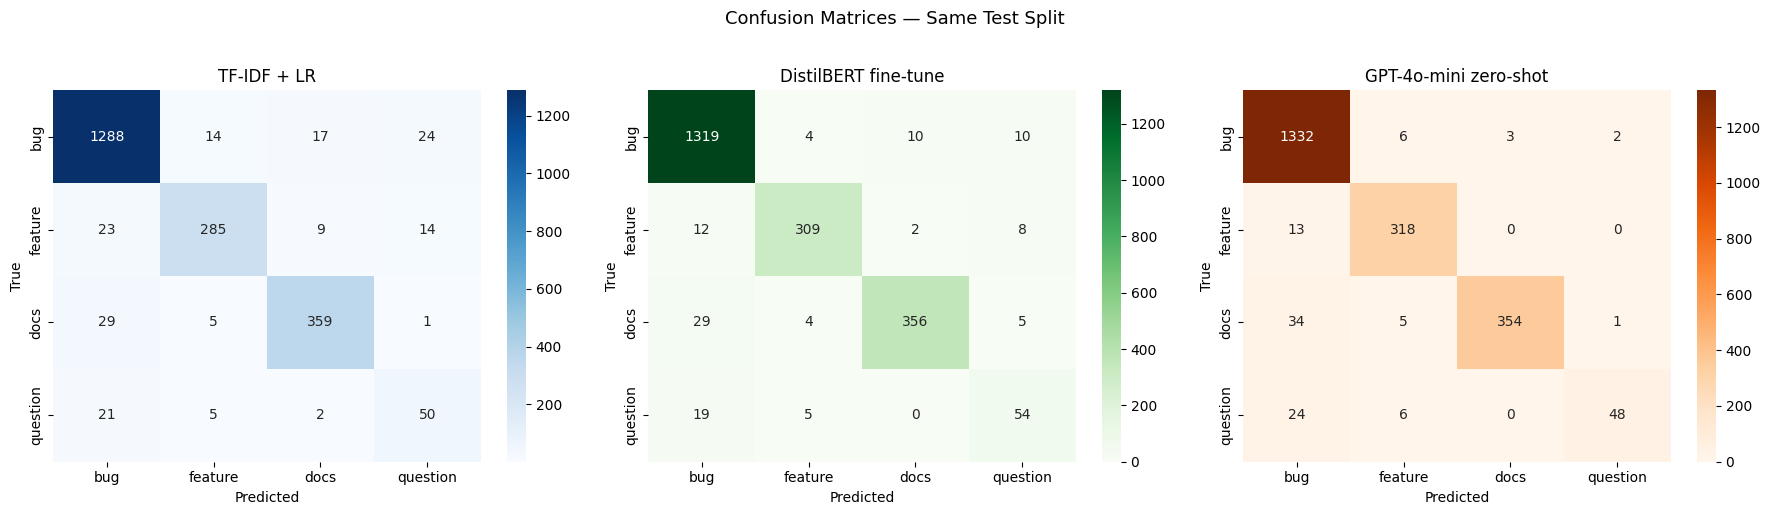


Highest test macro-F1: GPT-4o-mini zero-shot (0.9030)


In [15]:
# ── 8.1  Comparison table ──────────────────────────────────────────────────

all_results = [results_lr, results_distilbert, results_llm]

print("=" * 72)
print(f"{'Model':<28} {'Test F1':>9} {'Latency':>10} {'Cost/call':>12} {'Deployable?':>12}")
print("=" * 72)
for r in all_results:
    deployable = "YES" if r["cost_per_call"] == 0.0 and r["test_macro_f1"] > 0.75 else "marginal"
    print(
        f"{r['model']:<28}"
        f"{r['test_macro_f1']:>9.4f}"
        f"{str(round(r['latency_ms'])) + ' ms':>10}"
        f"{'$' + str(r['cost_per_call']):>12}"
        f"{deployable:>12}"
    )
print("=" * 72)

print("\nPer-class F1 breakdown:")
print(f"{'Model':<28}  ", "  ".join(f"{c:<10}" for c in CLASSES))
print("-" * 72)
for r in all_results:
    row = "  ".join(f"{r['per_class_f1'][c]:.4f}    " for c in CLASSES)
    print(f"{r['model']:<28}  {row}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cm, title, cmap in zip(
    axes,
    [cm_lr, cm_bert, cm_llm],
    ["TF-IDF + LR", "DistilBERT fine-tune", "GPT-4o-mini zero-shot"],
    ["Blues", "Greens", "Oranges"],
):
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASSES, yticklabels=CLASSES, cmap=cmap, ax=ax)
    ax.set_title(title)
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrices — Same Test Split", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / "cm_comparison.png", dpi=120)
plt.show()

best_model = max(all_results, key=lambda r: r["test_macro_f1"])
print(f"\nHighest test macro-F1: {best_model['model']} ({best_model['test_macro_f1']:.4f})")

## 9. Save Artifacts + Model Card

### Why SHA-256 the training data?
The API refuses to boot if the weights SHA-256 doesn't match the model card.
This prevents corrupted weights from silently serving wrong predictions.

### MinIO upload
The notebook tries MinIO first, then falls back to Google Drive.
After downloading from Drive, run `scripts/upload_to_minio.py` locally.


In [16]:
# ── 9.1  SHA-256 checksums + model card ────────────────────────────────────


def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(65536), b""):
            h.update(block)
    return h.hexdigest()


# Stable hash of training data (sort by number so row order doesn't matter)
train_json_bytes = json.dumps(
    [
        {"number": r["number"], "text": r["text"], "label": r["label"]}
        for r in sorted(train_records, key=lambda x: int(x["number"]))
    ],
    ensure_ascii=False,
).encode("utf-8")
training_data_sha256 = hashlib.sha256(train_json_bytes).hexdigest()
print(f"Training data SHA-256: {training_data_sha256}")

# Save weights FIRST so we can hash them
WEIGHTS_DIR = DATA_DIR / "distilbert_weights"
trainer.save_model(str(WEIGHTS_DIR))
tokenizer.save_pretrained(str(WEIGHTS_DIR))
print(f"DistilBERT weights saved to {WEIGHTS_DIR}")

weights_file = WEIGHTS_DIR / "model.safetensors"
if not weights_file.exists():
    weights_file = WEIGHTS_DIR / "pytorch_model.bin"
weights_sha256 = sha256_file(weights_file) if weights_file.exists() else ""
tfidf_sha256 = sha256_file(DATA_DIR / "tfidf_vectorizer.pkl")
lr_sha256 = sha256_file(DATA_DIR / "lr_model.pkl")
print(f"Weights SHA-256: {weights_sha256}")

model_card = {
    "architecture": MODEL_NAME,
    "task": "4-class GitHub issue classification",
    "classes": CLASSES,
    "label2id": LABEL2ID,
    "id2label": {str(i): c for i, c in ID2LABEL.items()},
    "freeze_policy": "full_fine_tune",
    "training_data": {
        "source": "pandas-dev/pandas closed issues",
        "n_train": len(X_train),
        "n_val": len(X_val),
        "n_test": len(X_test),
        "sha256": training_data_sha256,
    },
    "weights_sha256": weights_sha256,
    "tfidf_sha256": tfidf_sha256,
    "lr_sha256": lr_sha256,
    "hyperparameters": {
        "learning_rate": 2e-5,
        "batch_size": 16,
        "gradient_accumulation": 2,
        "max_length": MAX_TOKENS,
        "warmup_ratio": 0.10,
        "weight_decay": 0.01,
        "class_weights": dict(zip(CLASSES, normalized_weights.tolist())),
        "fp16": (DEVICE == "cuda"),
    },
    "metrics": {
        "distilbert": results_distilbert,
        "classical": results_lr,
        "llm": results_llm,
    },
    "created_at": datetime.now(UTC).isoformat(),
    "wandb_run": wandb.run.url if wandb.run else None,
}

model_card_path = DATA_DIR / "model_card.json"
model_card_path.write_text(json.dumps(model_card, indent=2))
print(f"Model card written to {model_card_path}")

Training data SHA-256: 59c6b6e2b336a01f59291c00071366b48d434812c3e7b337c9374e5f3adef71b


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT weights saved to /content/data/distilbert_weights
Weights SHA-256: e23b2bc3f2c50b0cc6491c57d4868bca61e0942824b070d0e1fca08e06a50e0c
Model card written to /content/data/model_card.json


In [17]:
# ── 9.2  Upload to MinIO (falls back to Google Drive) ─────────────────────

MINIO_BUCKET = "models"


def try_minio_upload() -> bool:
    try:
        mc = Minio(
            MINIO_ENDPOINT,
            access_key=MINIO_ACCESS,
            secret_key=MINIO_SECRET,
            secure=False,
        )
        if not mc.bucket_exists(MINIO_BUCKET):
            mc.make_bucket(MINIO_BUCKET)

        uploads = [
            (model_card_path, "distilbert/model_card.json"),
            (DATA_DIR / "tfidf_vectorizer.pkl", "classical/tfidf_vectorizer.pkl"),
            (DATA_DIR / "lr_model.pkl", "classical/lr_model.pkl"),
            (DATA_DIR / "cm_comparison.png", "plots/cm_comparison.png"),
        ]
        for wf in WEIGHTS_DIR.iterdir():
            uploads.append((wf, f"distilbert/{wf.name}"))

        for local_path, object_name in uploads:
            if Path(local_path).exists():
                mc.fput_object(MINIO_BUCKET, object_name, str(local_path))
                print(f"  Uploaded: {object_name}")
        return True
    except Exception as exc:
        print(f"MinIO upload failed: {exc}")
        return False


def save_to_drive() -> None:
    try:
        from google.colab import drive

        drive.mount("/content/drive")
        drive_dir = Path("/content/drive/MyDrive/maintainers-copilot-artifacts")
        drive_dir.mkdir(parents=True, exist_ok=True)
        import shutil

        shutil.copytree(DATA_DIR, drive_dir / "data", dirs_exist_ok=True)
        print(f"Artifacts saved to Google Drive: {drive_dir}")
        print("Run scripts/upload_to_minio.py locally to push to MinIO.")
    except Exception as exc:
        print(f"Google Drive save failed: {exc}")
        print(f"Artifacts are at {DATA_DIR} — download manually.")


print("Uploading artifacts ...")
if MINIO_ENDPOINT and try_minio_upload():
    print("All artifacts uploaded to MinIO.")
else:
    print("Falling back to Google Drive ...")
    save_to_drive()

Uploading artifacts ...


MinIO upload failed: HTTPConnectionPool(host='localhost', port=9000): Max retries exceeded with url: /models?location= (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7e074ff014c0>: Failed to establish a new connection: [Errno 111] Connection refused'))
Falling back to Google Drive ...
Mounted at /content/drive
Artifacts saved to Google Drive: /content/drive/MyDrive/maintainers-copilot-artifacts
Run scripts/upload_to_minio.py locally to push to MinIO.


In [18]:
# ── 9.3  Print submission block (copy into DECISIONS.md D-deploy) ──────────

print("=" * 68)
print("COPY THIS BLOCK INTO DECISIONS.md — D-deploy section")
print("=" * 68)
print()
print("Actual results on test split:")
for r in all_results:
    print(
        f"  {r['model']:<28}  macro-F1={r['test_macro_f1']:.4f}"
        f"  latency={r['latency_ms']}ms  cost/call=${r['cost_per_call']}"
    )

print()
print("Per-class F1:")
for r in all_results:
    per = "  ".join(f"{c}={r['per_class_f1'][c]:.4f}" for c in CLASSES)
    print(f"  {r['model']:<28}  {per}")

print()
print(f"Training data SHA-256: {training_data_sha256}")
print()
winner = max(all_results, key=lambda r: r["test_macro_f1"])
print(f"Deploying: {winner['model']}")
print(f"Reason: Highest test macro-F1 ({winner['test_macro_f1']:.4f}) with zero per-call cost.")
print()
print("Also update eval_thresholds.yaml:")
print("  classifier:")
print(f"    f1_macro:     {winner['test_macro_f1']:.2f}")
print(f"    classical_f1: {results_lr['test_macro_f1']:.4f}")
print(f"    dl_f1:        {results_distilbert['test_macro_f1']:.4f}")
print(f"    llm_f1:       {results_llm['test_macro_f1']:.4f}")
print("=" * 68)

COPY THIS BLOCK INTO DECISIONS.md — D-deploy section

Actual results on test split:
  TF-IDF + LR                   macro-F1=0.8404  latency=0.015ms  cost/call=$0.0
  DistilBERT fine-tune          macro-F1=0.8867  latency=469.6ms  cost/call=$0.0
  GPT-4o-mini zero-shot         macro-F1=0.9030  latency=775.0ms  cost/call=$7.8e-05

Per-class F1:
  TF-IDF + LR                   bug=0.9527  feature=0.8906  docs=0.9193  question=0.5988
  DistilBERT fine-tune          bug=0.9691  feature=0.9464  docs=0.9344  question=0.6968
  GPT-4o-mini zero-shot         bug=0.9701  feature=0.9550  docs=0.9427  question=0.7442

Training data SHA-256: 59c6b6e2b336a01f59291c00071366b48d434812c3e7b337c9374e5f3adef71b

Deploying: GPT-4o-mini zero-shot
Reason: Highest test macro-F1 (0.9030) with zero per-call cost.

Also update eval_thresholds.yaml:
  classifier:
    f1_macro:     0.90
    classical_f1: 0.8404
    dl_f1:        0.8867
    llm_f1:       0.9030
